In [1]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

%load_ext autoreload
%autoreload 2

ROOT = Path().cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

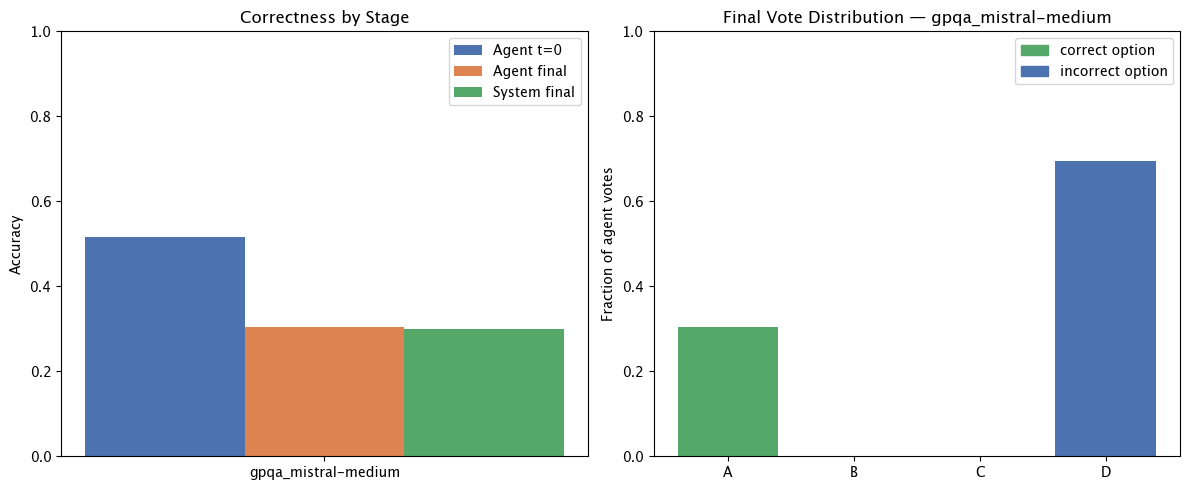

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

FILES = {
    'gpqa_mistral-medium': 'results/mas/20260518_134831_gpqa_mistral-medium_N4_T10_W1_topofc_temp0.7_q75_R50.json',
}

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def agent_votes_at_round(rep, round_idx):
    return [agent['vote'] for agent in rep['trajectory'][round_idx]['phase_b']]

def is_agent_correct_at_round(rep, round_idx):
    gt = rep['ground_truth']
    return [v == gt for v in agent_votes_at_round(rep, round_idx)]

records = []
vote_dist_records = []

for name, d in data.items():
    for rep in d['repetitions']:
        gt = rep['ground_truth']
        records.append({
            'dataset': name,
            'agent_correct_t0': np.mean(is_agent_correct_at_round(rep, 0)),
            'agent_correct_final': np.mean(is_agent_correct_at_round(rep, -1)),
            'system_correct': float(rep['correct']),
        })
        for vote in agent_votes_at_round(rep, -1):
            vote_dist_records.append({'dataset': name, 'vote': vote, 'ground_truth': gt})

df = pd.DataFrame(records)
vote_df = pd.DataFrame(vote_dist_records)
datasets = list(data.keys())

summary = df.groupby('dataset')[['agent_correct_t0', 'agent_correct_final', 'system_correct']].mean()

fig, axes = plt.subplots(1, 1 + len(datasets), figsize=(6 * (1 + len(datasets)), 5))
axes = np.atleast_1d(axes)

x = np.arange(len(summary))
width = 0.25
for i, (col, label, color) in enumerate(zip(
    ['agent_correct_t0', 'agent_correct_final', 'system_correct'],
    ['Agent t=0', 'Agent final', 'System final'],
    ['#4C72B0', '#DD8452', '#55A868']
)):
    axes[0].bar(x + i * width, summary[col], width, label=label, color=color)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(summary.index)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Correctness by Stage')
axes[0].legend()
axes[0].set_ylim(0, 1)

for ax, ds in zip(axes[1:], datasets):
    sub = vote_df[vote_df['dataset'] == ds]
    option_order_ds = sorted(data[ds]['repetitions'][0]['options'].keys())
    counts = sub['vote'].value_counts(normalize=True).reindex(option_order_ds, fill_value=0)
    gt_vals = set(sub['ground_truth'].unique())
    bar_colors = ['#55A868' if opt in gt_vals else '#4C72B0' for opt in option_order_ds]

    ax.bar(option_order_ds, counts.values, color=bar_colors)
    ax.set_ylabel('Fraction of agent votes')
    ax.set_title(f'Final Vote Distribution — {ds}')
    ax.set_ylim(0, 1)
    ax.legend(handles=[
        Patch(color='#55A868', label='correct option'),
        Patch(color='#4C72B0', label='incorrect option'),
    ])

plt.tight_layout()
plt.show()


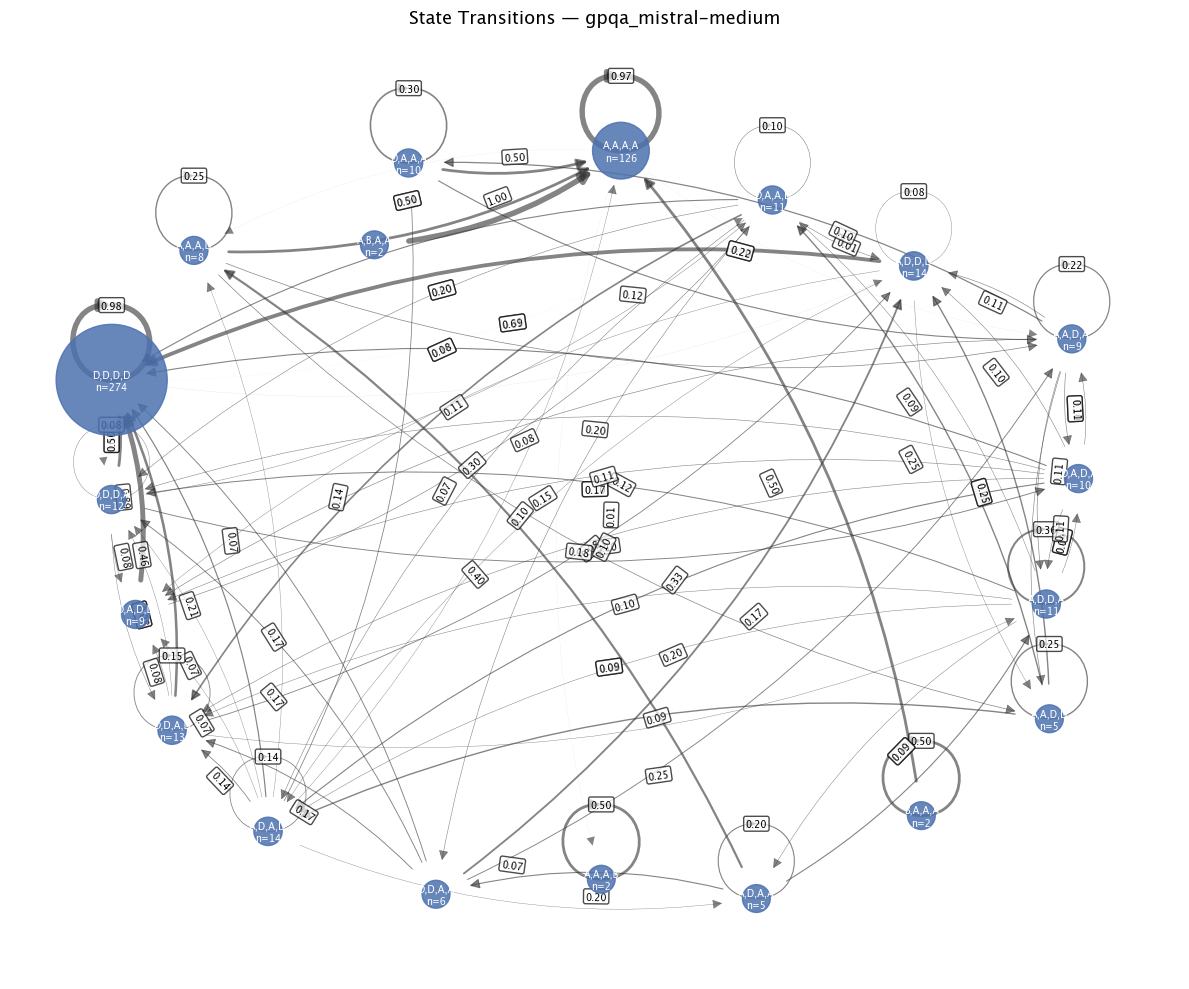

In [3]:
import json
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

FILES = {
    'gpqa_mistral-medium': 'results/mas/20260518_134831_gpqa_mistral-medium_N4_T10_W1_topofc_temp0.7_q75_R50.json',
}

MIN_VISITS = 2

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def build_transition_graph(d):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)

    for rep in d['repetitions']:
        states = [
            tuple(agent['vote'] for agent in step['phase_b'])
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    G = nx.DiGraph()
    for state, count in visit_counts.items():
        G.add_node(state, visits=count)
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G

def plot_transition_graph(G, title, ax, min_visits=1):
    visible = {n for n, d in G.nodes(data=True) if d['visits'] >= min_visits}
    G = G.subgraph(visible).copy()

    pos = nx.spring_layout(G, seed=42, k=2.5)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True))
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{','.join(n)}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.6, edge_color='#333333',
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle='arc3,rad=0.15',
        min_source_margin=25, min_target_margin=25,
    )
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_size=7, ax=ax,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
    )
    ax.set_title(title, fontsize=13)
    ax.axis('off')

n = len(data)
fig, axes = plt.subplots(1, n, figsize=(12 * n, 10), squeeze=False)
axes = axes[0]

for ax, (name, d) in zip(axes, data.items()):
    G = build_transition_graph(d)
    plot_transition_graph(G, f'State Transitions — {name}', ax, min_visits=MIN_VISITS)

plt.tight_layout()
plt.show()


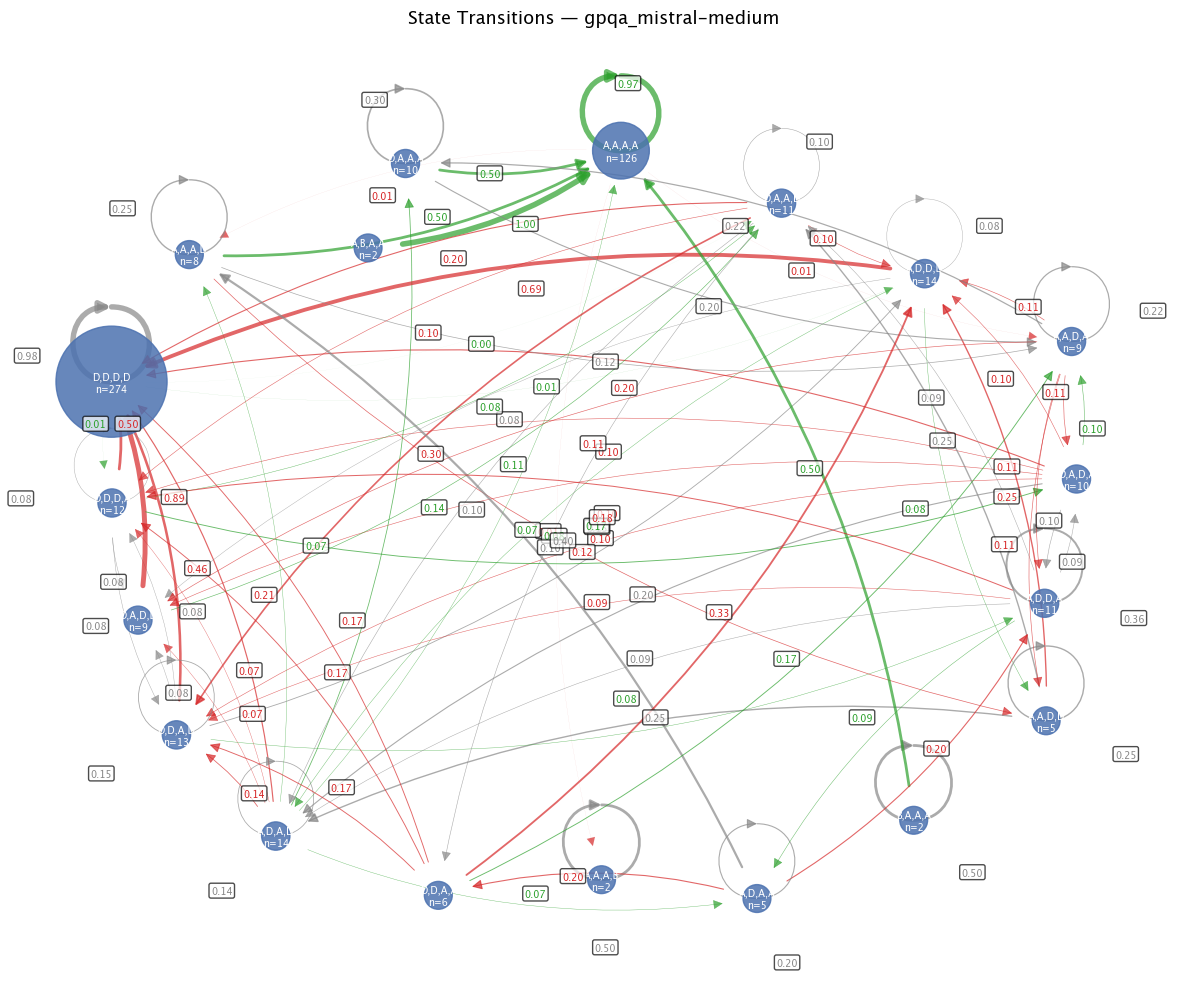

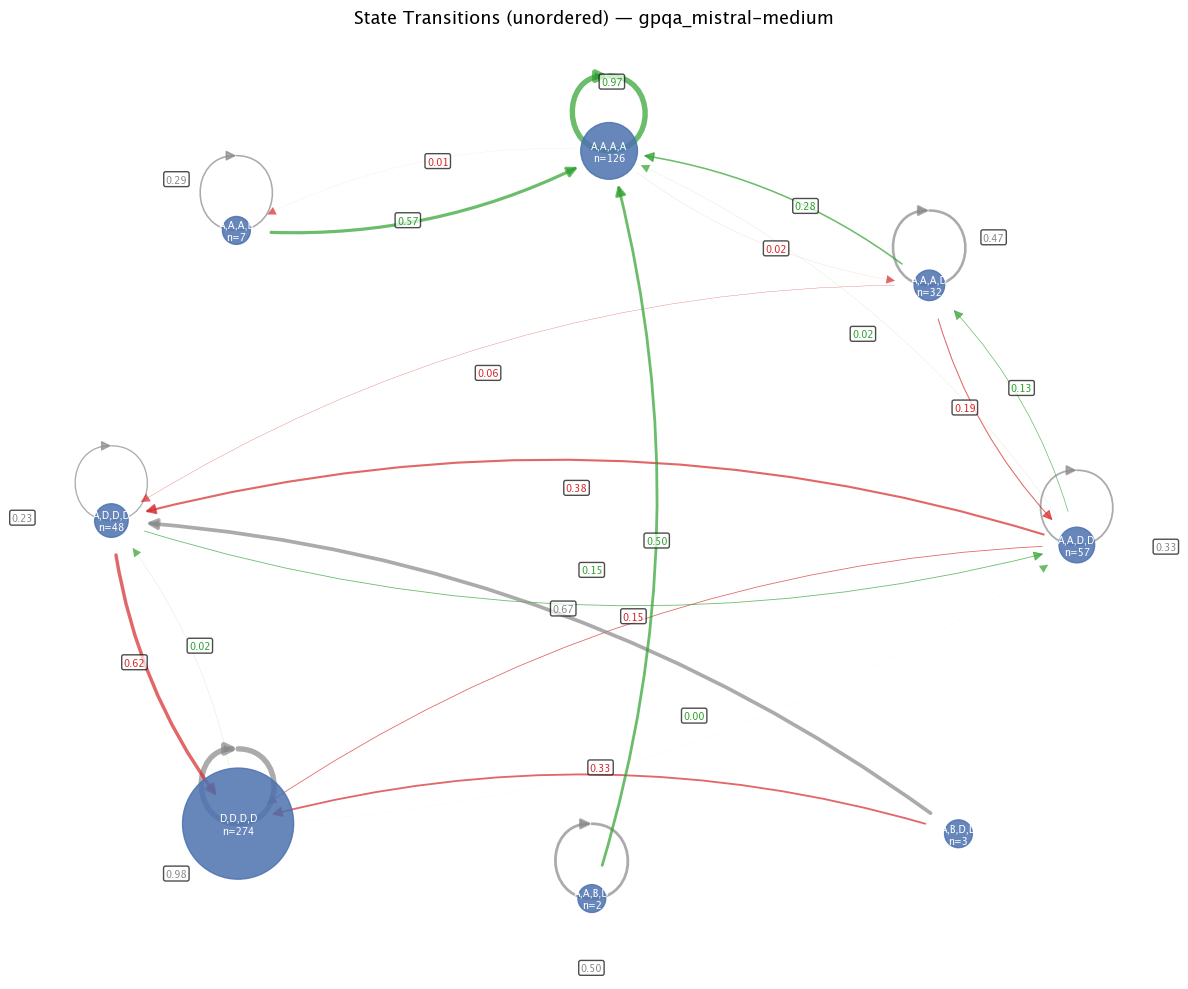

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

FILES = {
    'gpqa_mistral-medium': 'results/mas/20260518_134831_gpqa_mistral-medium_N4_T10_W1_topofc_temp0.7_q75_R50.json',
}

MIN_VISITS = 2
ARC_RAD = 0.15

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def build_transition_graph(d, unordered=False):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)

    for rep in d['repetitions']:
        states = [
            tuple(sorted(agent['vote'] for agent in step['phase_b']) if unordered
                  else [agent['vote'] for agent in step['phase_b']])
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    G = nx.DiGraph()
    for state, count in visit_counts.items():
        G.add_node(state, visits=count)
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G

def draw_arc_edge_labels(pos, edge_labels, edge_colors, ax, rad=ARC_RAD, font_size=7):
    all_positions = np.array(list(pos.values()))
    centroid = all_positions.mean(axis=0)

    for (u, v), label in edge_labels.items():
        p1 = np.array(pos[u])
        p2 = np.array(pos[v])
        color = edge_colors.get((u, v), '#888888')

        if u == v:
            away = p1 - centroid
            away_norm = np.linalg.norm(away)
            direction = away / away_norm if away_norm > 0 else np.array([0.0, 1.0])
            label_pos = p1 + direction * 0.18
        else:
            dx, dy = p2 - p1
            label_pos = (p1 + p2) / 2 + 0.5 * rad * np.array([dy, -dx])
            dists = np.linalg.norm(all_positions - label_pos, axis=1)
            nearest = all_positions[np.argmin(dists)]
            away = label_pos - nearest
            away_norm = np.linalg.norm(away)
            if away_norm > 0:
                label_pos += 0.05 * away / away_norm

        ax.text(
            label_pos[0], label_pos[1], label,
            fontsize=font_size, ha='center', va='center', zorder=5,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
        )

def plot_transition_graph(G, title, ax, gt, min_visits=1):
    visible = {n for n, d in G.nodes(data=True) if d['visits'] >= min_visits}
    G = G.subgraph(visible).copy()

    pos = nx.spring_layout(G, seed=42, k=4.0)

    def correct_count(state):
        return sum(1 for v in state if v == gt)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True))
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{','.join(n)}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    edge_color_map = {}
    for u, v in G.edges():
        if u == v:
            edge_color_map[(u, v)] = '#2ca02c' if correct_count(u) == len(u) else '#888888'
        else:
            delta = correct_count(v) - correct_count(u)
            if delta > 0:
                edge_color_map[(u, v)] = '#2ca02c'
            elif delta < 0:
                edge_color_map[(u, v)] = '#d62728'
            else:
                edge_color_map[(u, v)] = '#888888'

    edge_colors = [edge_color_map[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.7, edge_color=edge_colors,
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle=f'arc3,rad={ARC_RAD}',
        min_source_margin=25, min_target_margin=25,
    )
    draw_arc_edge_labels(pos, edge_labels, edge_color_map, ax)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

n = len(data)
fig, axes = plt.subplots(1, n, figsize=(12 * n, 10), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, data.items()):
    gt = d['repetitions'][0]['ground_truth']
    G = build_transition_graph(d)
    plot_transition_graph(G, f'State Transitions — {name}', ax, gt=gt, min_visits=MIN_VISITS)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, n, figsize=(12 * n, 10), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, data.items()):
    gt = d['repetitions'][0]['ground_truth']
    G = build_transition_graph(d, unordered=True)
    plot_transition_graph(G, f'State Transitions (unordered) — {name}', ax, gt=gt, min_visits=MIN_VISITS)
plt.tight_layout()
plt.show()


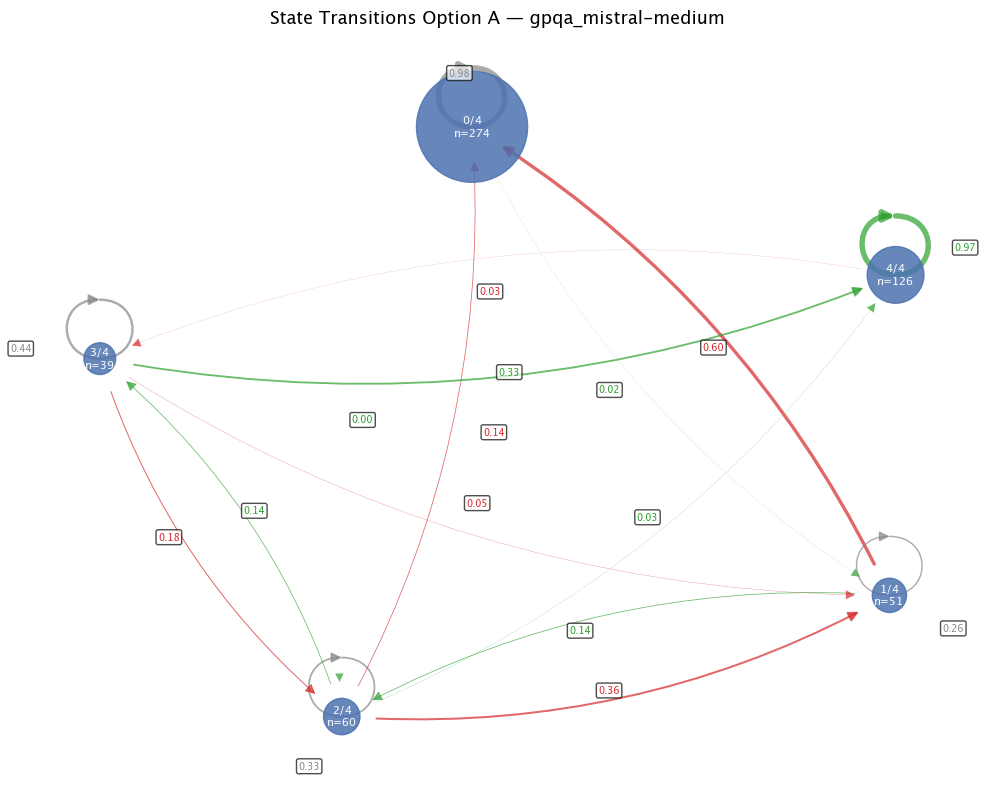

In [5]:
def build_transition_graph_option_a(d):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)
    gt = d['repetitions'][0]['ground_truth']

    for rep in d['repetitions']:
        states = [
            sum(1 for agent in step['phase_b'] if agent['vote'] == gt)
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    N = d['repetitions'][0]['N']
    G = nx.DiGraph()
    for k in range(N + 1):
        G.add_node(k, visits=visit_counts.get(k, 0))
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G, N

def plot_transition_graph_option_a(G, N, title, ax):
    pos = nx.spring_layout(G, seed=42, k=4.0)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True)) or 1
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{n}/{N}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    edge_color_map = {}
    for u, v in G.edges():
        if u == v:
            edge_color_map[(u, v)] = '#2ca02c' if u == N else '#888888'
        elif v > u:
            edge_color_map[(u, v)] = '#2ca02c'
        else:
            edge_color_map[(u, v)] = '#d62728'
    edge_colors = [edge_color_map[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.7, edge_color=edge_colors,
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle=f'arc3,rad={ARC_RAD}',
        min_source_margin=25, min_target_margin=25,
    )
    draw_arc_edge_labels(pos, edge_labels, edge_color_map, ax)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

n = len(data)
fig, axes = plt.subplots(1, n, figsize=(10 * n, 8), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, data.items()):
    G, N = build_transition_graph_option_a(d)
    plot_transition_graph_option_a(G, N, f'State Transitions Option A — {name}', ax)
plt.tight_layout()
plt.show()


 k  coverage  eligible  flip_rate  flipped
 1      0.98        48   0.145833        7
 2      0.96        46   0.108696        5
 3      0.92        46   0.065217        3
 4      0.90        44   0.045455        2
 5      0.86        41   0.024390        1
 6      0.82        38   0.026316        1
 7      0.76        36   0.027778        1
 8      0.72        27   0.037037        1
 9      0.54        16   0.062500        1
10      0.30         3   0.000000        0


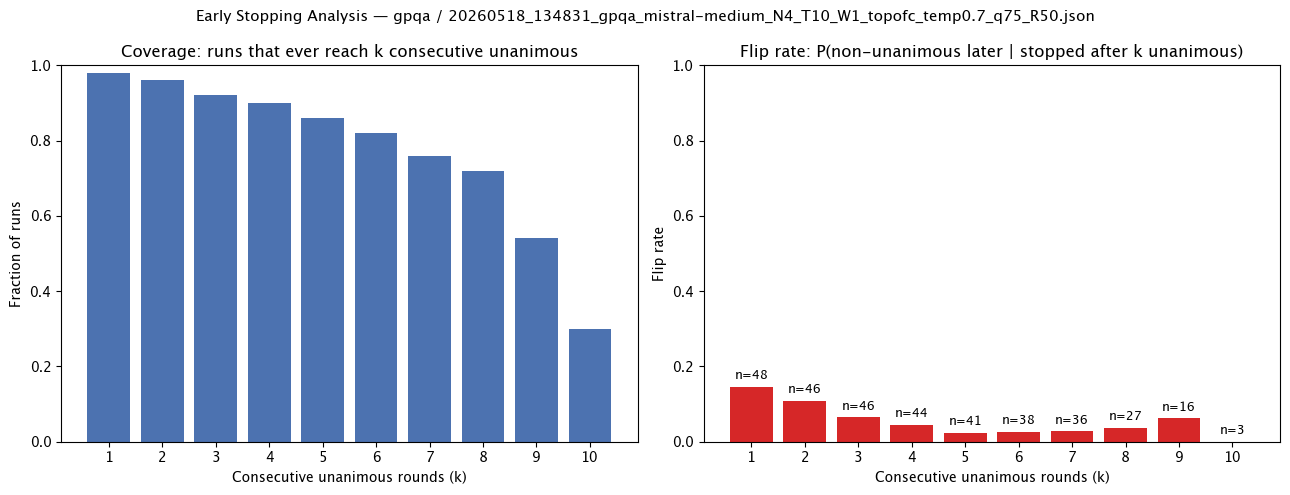

In [6]:
FILE_NEW = 'results/mas/20260518_134831_gpqa_mistral-medium_N4_T10_W1_topofc_temp0.7_q75_R50.json'

with open(ROOT / FILE_NEW) as f:
    d_new = json.load(f)

def unanimity_seq(rep):
    return [len(set(a['vote'] for a in step['phase_b'])) == 1 for step in rep['trajectory']]

def early_stopping_stats(d):
    seqs = [unanimity_seq(rep) for rep in d['repetitions']]
    T = max(len(s) for s in seqs)

    rows = []
    for k in range(1, T):
        covered = 0
        eligible = 0
        flipped = 0

        for seq in seqs:
            first_hit = next(
                (t for t in range(k - 1, len(seq)) if all(seq[t - k + 1: t + 1])),
                None
            )
            if first_hit is None:
                continue
            covered += 1
            if first_hit < len(seq) - 1:
                eligible += 1
                if any(not s for s in seq[first_hit + 1:]):
                    flipped += 1

        rows.append({
            'k': k,
            'coverage': covered / len(seqs),
            'eligible': eligible,
            'flip_rate': flipped / eligible if eligible > 0 else float('nan'),
            'flipped': flipped,
        })

    return pd.DataFrame(rows)

stats = early_stopping_stats(d_new)
print(stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(stats['k'], stats['coverage'], color='#4C72B0')
axes[0].set_xlabel('Consecutive unanimous rounds (k)')
axes[0].set_ylabel('Fraction of runs')
axes[0].set_title('Coverage: runs that ever reach k consecutive unanimous')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(stats['k'])

axes[1].bar(stats['k'], stats['flip_rate'], color='#d62728')
axes[1].set_xlabel('Consecutive unanimous rounds (k)')
axes[1].set_ylabel('Flip rate')
axes[1].set_title('Flip rate: P(non-unanimous later | stopped after k unanimous)')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(stats['k'])
for i, row in stats.iterrows():
    if not np.isnan(row['flip_rate']):
        axes[1].text(row['k'], row['flip_rate'] + 0.02, f"n={int(row['eligible'])}", ha='center', fontsize=9)

plt.suptitle(f"Early Stopping Analysis — {d_new['dataset']} / {FILE_NEW.split('/')[-1]}", fontsize=11)
plt.tight_layout()
plt.show()


In [7]:
K_ANALYZE = 3

def vote_at_stop(rep, stop_round):
    votes = [a['vote'] for a in rep['trajectory'][stop_round]['phase_b']]
    assert len(set(votes)) == 1
    return votes[0]

def majority_vote(rep, round_idx):
    votes = [a['vote'] for a in rep['trajectory'][round_idx]['phase_b']]
    return max(set(votes), key=votes.count)

flip_records = []

for rep in d_new['repetitions']:
    seq = unanimity_seq(rep)
    gt = rep['ground_truth']
    T = len(seq)

    first_hit = next(
        (t for t in range(K_ANALYZE - 1, T) if all(seq[t - K_ANALYZE + 1: t + 1])),
        None
    )
    if first_hit is None or first_hit >= T - 1:
        continue

    later = seq[first_hit + 1:]
    if not any(not s for s in later):
        continue

    stop_vote = vote_at_stop(rep, first_hit)
    final_vote = majority_vote(rep, -1)

    flip_records.append({
        'question_id': rep['question_id'],
        'stop_round': first_hit,
        'stop_correct': stop_vote == gt,
        'final_correct': final_vote == gt,
        'stop_vote': stop_vote,
        'final_vote': final_vote,
        'ground_truth': gt,
        'outcome': (
            'correct → correct' if stop_vote == gt and final_vote == gt else
            'correct → wrong'   if stop_vote == gt and final_vote != gt else
            'wrong → correct'   if stop_vote != gt and final_vote == gt else
            'wrong → wrong'
        )
    })

flip_df = pd.DataFrame(flip_records)
print(f"k={K_ANALYZE}: {len(flip_df)} flip cases\n")
print(flip_df[['question_id', 'stop_round', 'stop_vote', 'final_vote', 'ground_truth', 'outcome']].to_string(index=False))


k=3: 3 flip cases

question_id  stop_round stop_vote final_vote ground_truth           outcome
         75           3         A          A            A correct → correct
         75           7         D          D            A     wrong → wrong
         75           3         D          D            A     wrong → wrong


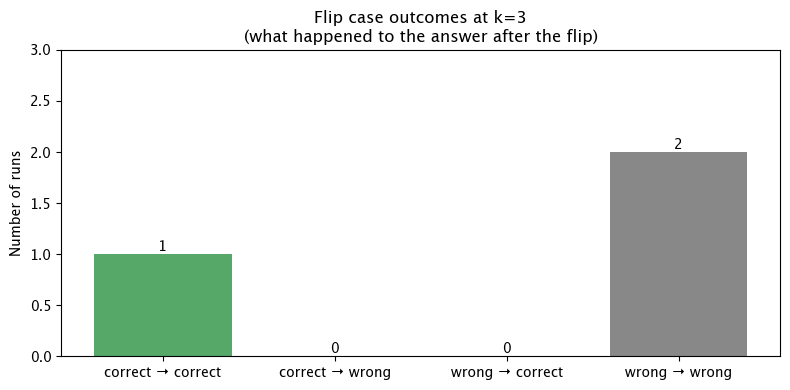

In [8]:
outcome_colors = {
    'correct → correct': '#55A868',
    'correct → wrong':   '#d62728',
    'wrong → correct':   '#4C72B0',
    'wrong → wrong':     '#888888',
}

counts = flip_df['outcome'].value_counts().reindex(outcome_colors.keys(), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color=[outcome_colors[o] for o in counts.index])
ax.bar_label(bars)
ax.set_ylabel('Number of runs')
ax.set_title(f'Flip case outcomes at k={K_ANALYZE}\n(what happened to the answer after the flip)')
ax.set_ylim(0, counts.max() + 1)
plt.tight_layout()
plt.show()


outcome  correct → correct  correct → wrong  wrong → correct  wrong → wrong
k                                                                          
1                        2                1                0              4
2                        2                0                0              3
3                        1                0                0              2
4                        1                0                0              1
5                        0                0                0              1
6                        0                0                0              1
7                        0                0                0              1
8                        0                0                0              1
9                        0                0                0              1


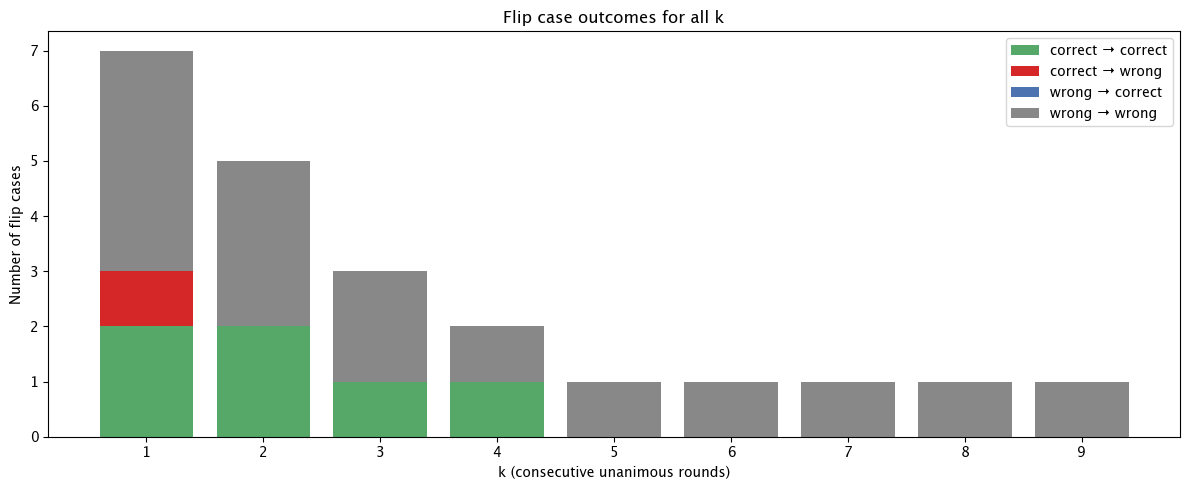

In [9]:
all_flip_records = []

for k in range(1, max(len(unanimity_seq(rep)) for rep in d_new['repetitions'])):
    for rep in d_new['repetitions']:
        seq = unanimity_seq(rep)
        gt = rep['ground_truth']
        T = len(seq)

        first_hit = next(
            (t for t in range(k - 1, T) if all(seq[t - k + 1: t + 1])),
            None
        )
        if first_hit is None or first_hit >= T - 1:
            continue
        if not any(not s for s in seq[first_hit + 1:]):
            continue

        stop_vote = vote_at_stop(rep, first_hit)
        final_vote = majority_vote(rep, -1)

        all_flip_records.append({
            'k': k,
            'question_id': rep['question_id'],
            'stop_correct': stop_vote == gt,
            'final_correct': final_vote == gt,
            'outcome': (
                'correct → correct' if stop_vote == gt and final_vote == gt else
                'correct → wrong'   if stop_vote == gt and final_vote != gt else
                'wrong → correct'   if stop_vote != gt and final_vote == gt else
                'wrong → wrong'
            )
        })

all_flip_df = pd.DataFrame(all_flip_records)

summary = (
    all_flip_df.groupby(['k', 'outcome'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['correct → correct', 'correct → wrong', 'wrong → correct', 'wrong → wrong'], fill_value=0)
)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = summary.index
bottom = np.zeros(len(x))
for outcome, color in outcome_colors.items():
    if outcome in summary.columns:
        vals = summary[outcome].values
        ax.bar(x, vals, bottom=bottom, label=outcome, color=color)
        bottom += vals

ax.set_xlabel('k (consecutive unanimous rounds)')
ax.set_ylabel('Number of flip cases')
ax.set_title('Flip case outcomes for all k')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()


 k  triggered_frac  mean_rounds_saved  median_rounds_saved  mean_rounds_saved_when_triggered
 1            0.98               7.38                  8.0                          7.530612
 2            0.96               6.20                  7.0                          6.458333
 3            0.92               5.16                  6.0                          5.608696
 4            0.90               4.20                  5.0                          4.666667
 5            0.86               3.22                  4.0                          3.744186
 6            0.82               2.40                  3.0                          2.926829
 7            0.76               1.64                  2.0                          2.157895
 8            0.72               0.92                  1.0                          1.277778
 9            0.54               0.38                  0.0                          0.703704
10            0.30               0.06                  0.0            

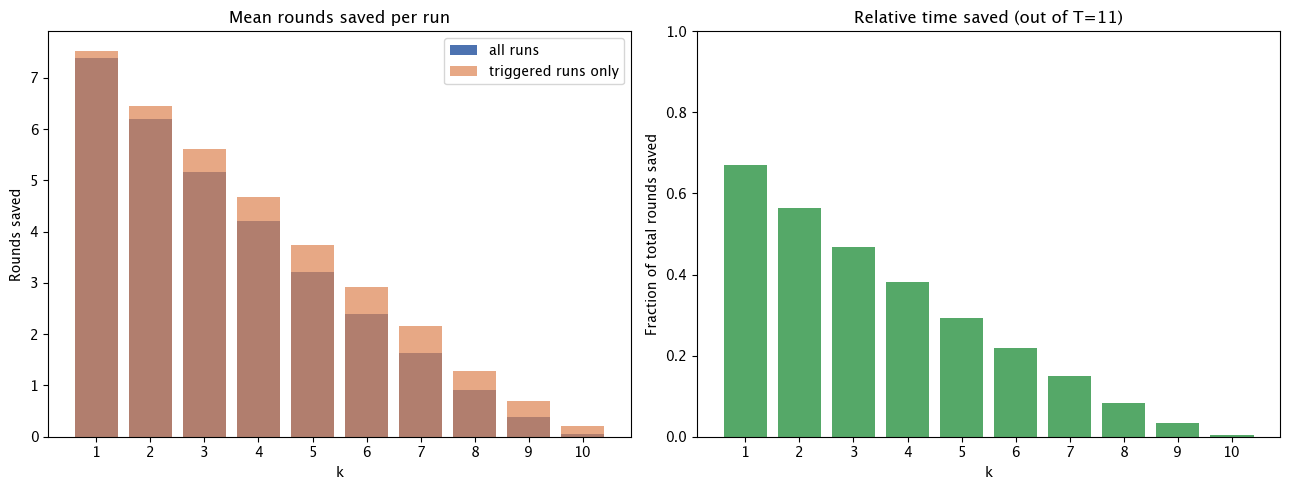

In [10]:
time_records = []

for k in range(1, max(len(unanimity_seq(rep)) for rep in d_new['repetitions'])):
    saved = []
    not_triggered = []

    for rep in d_new['repetitions']:
        seq = unanimity_seq(rep)
        T = len(seq)

        first_hit = next(
            (t for t in range(k - 1, T) if all(seq[t - k + 1: t + 1])),
            None
        )
        if first_hit is not None:
            saved.append(T - 1 - first_hit)
        else:
            not_triggered.append(0)

    all_savings = saved + not_triggered
    time_records.append({
        'k': k,
        'triggered_frac': len(saved) / len(d_new['repetitions']),
        'mean_rounds_saved': np.mean(all_savings),
        'median_rounds_saved': np.median(all_savings),
        'mean_rounds_saved_when_triggered': np.mean(saved) if saved else float('nan'),
    })

time_df = pd.DataFrame(time_records)
print(time_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(time_df['k'], time_df['mean_rounds_saved'], color='#4C72B0', label='all runs')
axes[0].bar(time_df['k'], time_df['mean_rounds_saved_when_triggered'], color='#DD8452', alpha=0.7, label='triggered runs only')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Rounds saved')
axes[0].set_title('Mean rounds saved per run')
axes[0].set_xticks(time_df['k'])
axes[0].legend()

T_total = max(len(rep['trajectory']) for rep in d_new['repetitions'])
axes[1].bar(time_df['k'], time_df['mean_rounds_saved'] / T_total, color='#55A868')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Fraction of total rounds saved')
axes[1].set_title(f'Relative time saved (out of T={T_total})')
axes[1].set_xticks(time_df['k'])
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
